In [ ]:
import requests
import pandas as pd 
import numpy as np
import time 
import calendar
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from sklearn.preprocessing import RobustScaler
import datetime
from datetime import timedelta
from sklearn.metrics import classification_report,confusion_matrix,precision_recall_curve,accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt 
import pickle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,GRU,Dense,Dropout,Bidirectional,BatchNormalization,Input,LayerNormalization 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import tensorflow as tf 

In [2]:
api_key='b0b16ad6834c4ebea1b181e3afa92e21'
technical='time_series'
ticker='BTC/USD'
timezone='Asia/Calcutta'
interval='5min'

In [189]:
data=[]
session=requests.Session()
retries=Retry(total=5,backoff_factor=1,status_forcelist=[429,500,502,503,504])
session.mount("https://",HTTPAdapter(max_retries=retries))
for yr in range(2022,2026):
    for m in range(1,13):
        start_date=f'{yr}-{m:02d}-01T00:00:00'
        end_date=f'{yr}-{m:02d}-15T23:55:00'
        api_url=f'https://api.twelvedata.com/{technical}?symbol={ticker}&order=asc&timezone={timezone}&start_date={start_date}&end_date={end_date}&interval={interval}&outputsize=5000&apikey={api_key}'
        while True:
            fetch=session.get(api_url).json()
            if "values" in fetch:
                df=pd.DataFrame(fetch['values'])
                data.append(df)
                time.sleep(2)
                break
            elif "code" in fetch and fetch["code"]==429:
                print("Rate limit exceeded")
                time.sleep(15)
            else: 
                print("API Error:",fetch)
                fetch=None
                break
        last_day=calendar.monthrange(yr,m)[1]
        start_date=f'{yr}-{m:02d}-16T00:00:00'
        end_date=f'{yr}-{m:02d}-{last_day}T23:55:00'
        api_url=f'https://api.twelvedata.com/{technical}?symbol={ticker}&order=asc&timezone={timezone}&start_date={start_date}&end_date={end_date}&interval={interval}&outputsize=5000&apikey={api_key}'
        while True:
            fetch=session.get(api_url).json()
            if "values" in fetch:
                df=pd.DataFrame(fetch['values'])
                data.append(df)
                time.sleep(2)
                break
            elif "code" in fetch and fetch["code"]==429:
                print("Rate limit exceeded")
                time.sleep(15)
            else: 
                print("API Error:",fetch)
                fetch=None
                break
for m in range(1,5):
    start_date=f'2026-{m:02d}-01T00:00:00'
    end_date=f'2026-{m:02d}-15T23:55:00'
    api_url=f'https://api.twelvedata.com/{technical}?symbol={ticker}&order=asc&timezone={timezone}&start_date={start_date}&end_date={end_date}&interval={interval}&outputsize=5000&apikey={api_key}'
    while True:
        fetch=session.get(api_url).json()
        if "values" in fetch:
            df=pd.DataFrame(fetch['values'])
            data.append(df)
            time.sleep(2)
            break
        elif "code" in fetch and fetch["code"]==429:
            print("Rate limit exceeded")
            time.sleep(15)
        else: 
            print("API Error:",fetch)
            fetch=None
            break
    last_day=calendar.monthrange(2026,m)[1]
    start_date=f'2026-{m:02d}-16T00:00:00'
    end_date=f'2026-{m:02d}-{last_day}T23:55:00'
    api_url=f'https://api.twelvedata.com/{technical}?symbol={ticker}&order=asc&timezone={timezone}&start_date={start_date}&end_date={end_date}&interval={interval}&outputsize=5000&apikey={api_key}'
    while True:
        fetch=session.get(api_url).json()
        if "values" in fetch:
            df=pd.DataFrame(fetch['values'])
            data.append(df)
            time.sleep(2)
            break
        elif "code" in fetch and fetch["code"]==429:
            print("Rate limit exceeded")
            time.sleep(15)
        else: 
            print("API Error:",fetch)
            fetch=None
            break
data=pd.concat(data,ignore_index=True)
data['color']=np.where(data['close']>data['open'],1,0)
data['open']=pd.to_numeric(data['open'])
data['close']=pd.to_numeric(data['close'])
data['abs_body']=abs(data['close']-data['open'])
data['body']=(data['close']-data['open'])
data['high']=pd.to_numeric(data['high'])
data['low']=pd.to_numeric(data['low'])
data

Rate limit exceeded
Rate limit exceeded
Rate limit exceeded
Rate limit exceeded
Rate limit exceeded
Rate limit exceeded
Rate limit exceeded
Rate limit exceeded
Rate limit exceeded
Rate limit exceeded
Rate limit exceeded
Rate limit exceeded
Rate limit exceeded
Rate limit exceeded
Rate limit exceeded
Rate limit exceeded
Rate limit exceeded
Rate limit exceeded
Rate limit exceeded
Rate limit exceeded


,datetime,open,high,low,close,color,abs_body,body
0,2022-01-01 00:00:00,46894.30078,46948.67188,46868.339840,46912.83984,1,18.53906,18.53906
1,2022-01-01 00:05:00,46906.39844,46951.76953,46858.718750,46870.67188,0,35.72656,-35.72656
2,2022-01-01 00:10:00,46876.62109,46903.30078,46557.179690,46688.80859,0,187.81250,-187.81250
3,2022-01-01 00:15:00,46691.37109,46757.39062,46640.929690,46689.69922,0,1.67187,-1.67187
4,2022-01-01 00:20:00,46686.78906,46724.30078,46631.058594,46658.69141,0,28.09765,-28.09765
...,...,...,...,...,...,...,...,...
454046,2026-04-30 23:35:00,76292.01000,76292.01000,76235.900000,76266.84000,0,25.17000,-25.17000
454047,2026-04-30 23:40:00,76267.20000,76267.20000,76209.730000,76230.76000,0,36.44000,-36.44000
454048,2026-04-30 23:45:00,76230.76000,76440.01000,76225.500000,76384.66000,1,153.90000,153.90000
454049,2026-04-30 23:50:00,76384.66000,76405.49000,76354.200000,76370.97000,0,13.69000,-13.69000


In [190]:
df_volume=[]
df_takervolume=[]
df_opentime=[]
df_trades=[]
interval='5m'
session=requests.Session()
retries=Retry(total=5,backoff_factor=1,status_forcelist=[429,500,502,503,504])
session.mount("https://",HTTPAdapter(max_retries=retries))
start_ms=int(datetime.datetime(2022,1,1).timestamp()*1000)
end_ms=int(datetime.datetime(2026,5,1).timestamp()*1000)
while start_ms<end_ms:
    api_url=f"https://api1.binance.com/api/v3/klines?symbol=BTCUSDT&interval={interval}&startTime={start_ms}&endTime={end_ms}&limit=1000"
    fetch=session.get(api_url).json()
    if fetch:
        open_time=[value[0] for value in fetch]
        volume=[float(value[7]) for value in fetch]
        taker_volume=[float(value[10]) for value in fetch]
        trades=[float(value[8]) for value in fetch]
        df_volume.extend(volume)
        df_opentime.extend(open_time) 
        df_takervolume.extend(taker_volume)
        df_trades.extend(trades)
        start_ms=fetch[-1][6]+1
        time.sleep(0.1)
    else: 
        print("API Error:",fetch)
        fetch=None
df=pd.DataFrame({
    'open_time':pd.to_datetime(df_opentime,unit='ms'),
    'volume':df_volume,
    'taker_volume':df_takervolume,
    'no_of_trades':df_trades
}).dropna()
df

,open_time,volume,taker_volume,no_of_trades
0,2021-12-31 19:30:00,4.435880e+07,1.873171e+07,14992.0
1,2021-12-31 19:35:00,9.097268e+06,5.151974e+06,4642.0
2,2021-12-31 19:40:00,8.772587e+06,4.049657e+06,4463.0
3,2021-12-31 19:45:00,1.337218e+07,6.338865e+06,6641.0
4,2021-12-31 19:50:00,2.239187e+07,7.908170e+06,10891.0
...,...,...,...,...
455308,2026-04-30 19:10:00,1.477471e+06,4.709503e+05,4882.0
455309,2026-04-30 19:15:00,1.856047e+06,1.288829e+06,5578.0
455310,2026-04-30 19:20:00,1.666661e+06,1.390004e+06,8120.0
455311,2026-04-30 19:25:00,2.146116e+06,1.599498e+06,7676.0


In [191]:
data['datetime']=pd.to_datetime(data['datetime'],format='%Y-%m-%d %H:%M:%S')
data=data.sort_values('datetime').reset_index(drop=True)
data['datetime']=data['datetime'].dt.tz_localize('UTC').dt.tz_convert('Asia/Kolkata').dt.tz_localize(None)
df['open_time']=pd.to_datetime(df['open_time'])
df=df.sort_values('open_time').reset_index(drop=True)
df['open_time']=df['open_time'].dt.tz_localize('UTC').dt.tz_convert('Asia/Kolkata').dt.tz_localize(None)
merged_data=pd.merge_asof(data,df,left_on='datetime',right_on='open_time',direction='nearest',tolerance=pd.Timedelta('15min'))
data=merged_data
data

,datetime,open,high,low,close,color,abs_body,body,open_time,volume,taker_volume,no_of_trades
0,2022-01-01 05:30:00,46894.30078,46948.67188,46868.339840,46912.83984,1,18.53906,18.53906,2022-01-01 05:30:00,8.598314e+06,4.933083e+06,4551.0
1,2022-01-01 05:35:00,46906.39844,46951.76953,46858.718750,46870.67188,0,35.72656,-35.72656,2022-01-01 05:35:00,5.730875e+06,2.836664e+06,3937.0
2,2022-01-01 05:40:00,46876.62109,46903.30078,46557.179690,46688.80859,0,187.81250,-187.81250,2022-01-01 05:40:00,3.592816e+06,1.988818e+06,2616.0
3,2022-01-01 05:45:00,46691.37109,46757.39062,46640.929690,46689.69922,0,1.67187,-1.67187,2022-01-01 05:45:00,4.682187e+06,3.036235e+06,3065.0
4,2022-01-01 05:50:00,46686.78906,46724.30078,46631.058594,46658.69141,0,28.09765,-28.09765,2022-01-01 05:50:00,6.273260e+06,3.244493e+06,3316.0
...,...,...,...,...,...,...,...,...,...,...,...,...
454046,2026-05-01 05:05:00,76292.01000,76292.01000,76235.900000,76266.84000,0,25.17000,-25.17000,NaT,NaN,NaN,NaN
454047,2026-05-01 05:10:00,76267.20000,76267.20000,76209.730000,76230.76000,0,36.44000,-36.44000,NaT,NaN,NaN,NaN
454048,2026-05-01 05:15:00,76230.76000,76440.01000,76225.500000,76384.66000,1,153.90000,153.90000,NaT,NaN,NaN,NaN
454049,2026-05-01 05:20:00,76384.66000,76405.49000,76354.200000,76370.97000,0,13.69000,-13.69000,NaT,NaN,NaN,NaN


In [175]:
data=pd.read_csv('BTC_22-26_5min.csv')

In [ ]:
data['upper_wick']=np.where(data['color']==1,data['high']-data['close'],data['high']-data['open'])
data['lower_wick']=np.where(data['color']==1,data['open']-data['low'],data['close']-data['low'])
data['body_to_range']=data['body']/(data['high']-data['low']+1e-10)
data['upper_wick_ratio']=data['upper_wick']/(data['high']-data['low']+1e-10)
data['lower_wick_ratio']=data['lower_wick']/(data['high']-data['low']+1e-10)
data['price_change']=data['close'].pct_change(10)
data['price_change_2']=data['close'].pct_change(20)
data['price_change_3']=data['close'].pct_change(30)
data['price_change_4']=data['close'].pct_change(40)
data['sma_10']=data['close'].rolling(30).mean()
data['close_to_sma10']=(data['close']-data['sma_10'])/data['sma_10']
data['volatility']=data['close'].rolling(30).std()
data['volume']=pd.to_numeric(data['volume'])
data['taker_volume']=pd.to_numeric(data['taker_volume'])
data['no_of_trades']=pd.to_numeric(data['no_of_trades'])
data['taker_buy_ratio']=data['taker_volume']/(data['volume']+1e-10)
data['avg_trade_size']=data['volume']/(data['no_of_trades']+1e-10)
data['datetime']=pd.to_datetime(data['datetime'])
data.set_index('datetime',inplace=True)
data['realised_vol']=data['close'].pct_change().rolling(12).std()
FORWARD_BARS=24
UP_THRESH=0.001
DN_THRESH=-0.001
future_return=(data['close'].shift(-FORWARD_BARS)-data['close'])/data['close']  
data['label']=np.where(future_return>UP_THRESH,1,np.where(future_return<DN_THRESH,0,np.nan))  

In [177]:
data['date']=data.index.date
data

,Unnamed: 0,open,high,low,close,color,abs_body,body,open_time,volume,...,price_change_3,price_change_4,sma_10,close_to_sma10,volatility,taker_buy_ratio,avg_trade_size,realised_vol,label,date
datetime,,,,,,,,,,,,,,,,,,,,,
2022-01-01 05:30:00,0,46894.30078,46948.67188,46868.339840,46912.83984,1,18.53906,18.53906,2022-01-01 05:30:00,8.598314e+06,...,NaN,NaN,NaN,NaN,NaN,0.573727,1889.324186,NaN,0.0,2022-01-01
2022-01-01 05:35:00,1,46906.39844,46951.76953,46858.718750,46870.67188,0,35.72656,-35.72656,2022-01-01 05:35:00,5.730875e+06,...,NaN,NaN,NaN,NaN,NaN,0.494979,1455.645051,NaN,0.0,2022-01-01
2022-01-01 05:40:00,2,46876.62109,46903.30078,46557.179690,46688.80859,0,187.81250,-187.81250,2022-01-01 05:40:00,3.592816e+06,...,NaN,NaN,NaN,NaN,NaN,0.553554,1373.400434,NaN,0.0,2022-01-01
2022-01-01 05:45:00,3,46691.37109,46757.39062,46640.929690,46689.69922,0,1.67187,-1.67187,2022-01-01 05:45:00,4.682187e+06,...,NaN,NaN,NaN,NaN,NaN,0.648465,1527.630485,NaN,0.0,2022-01-01
2022-01-01 05:50:00,4,46686.78906,46724.30078,46631.058594,46658.69141,0,28.09765,-28.09765,2022-01-01 05:50:00,6.273260e+06,...,NaN,NaN,NaN,NaN,NaN,0.517194,1891.815430,NaN,0.0,2022-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-01 05:05:00,454046,76292.01000,76292.01000,76235.900000,76266.84000,0,25.17000,-25.17000,NaN,NaN,...,-0.002425,-0.001161,76280.387333,-0.000178,110.465877,NaN,NaN,0.000696,NaN,2026-05-01
2026-05-01 05:10:00,454047,76267.20000,76267.20000,76209.730000,76230.76000,0,36.44000,-36.44000,NaN,NaN,...,-0.002572,-0.001339,76273.835667,-0.000565,107.232821,NaN,NaN,0.000555,NaN,2026-05-01
2026-05-01 05:15:00,454048,76230.76000,76440.01000,76225.500000,76384.66000,1,153.90000,153.90000,NaN,NaN,...,-0.000175,0.001530,76273.390667,0.001459,106.726251,NaN,NaN,0.000725,NaN,2026-05-01


In [ ]:
df=data.between_time('00:00','23:55')
df

,Unnamed: 0,open,high,low,close,color,abs_body,body,open_time,volume,...,price_change_3,price_change_4,sma_10,close_to_sma10,volatility,taker_buy_ratio,avg_trade_size,realised_vol,label,date
datetime,,,,,,,,,,,,,,,,,,,,,
2022-01-01 05:30:00,0,46894.30078,46948.67188,46868.339840,46912.83984,1,18.53906,18.53906,2022-01-01 05:30:00,8.598314e+06,...,NaN,NaN,NaN,NaN,NaN,0.573727,1889.324186,NaN,0.0,2022-01-01
2022-01-01 05:35:00,1,46906.39844,46951.76953,46858.718750,46870.67188,0,35.72656,-35.72656,2022-01-01 05:35:00,5.730875e+06,...,NaN,NaN,NaN,NaN,NaN,0.494979,1455.645051,NaN,0.0,2022-01-01
2022-01-01 05:40:00,2,46876.62109,46903.30078,46557.179690,46688.80859,0,187.81250,-187.81250,2022-01-01 05:40:00,3.592816e+06,...,NaN,NaN,NaN,NaN,NaN,0.553554,1373.400434,NaN,0.0,2022-01-01
2022-01-01 05:45:00,3,46691.37109,46757.39062,46640.929690,46689.69922,0,1.67187,-1.67187,2022-01-01 05:45:00,4.682187e+06,...,NaN,NaN,NaN,NaN,NaN,0.648465,1527.630485,NaN,0.0,2022-01-01
2022-01-01 05:50:00,4,46686.78906,46724.30078,46631.058594,46658.69141,0,28.09765,-28.09765,2022-01-01 05:50:00,6.273260e+06,...,NaN,NaN,NaN,NaN,NaN,0.517194,1891.815430,NaN,0.0,2022-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-01 05:05:00,454046,76292.01000,76292.01000,76235.900000,76266.84000,0,25.17000,-25.17000,NaN,NaN,...,-0.002425,-0.001161,76280.387333,-0.000178,110.465877,NaN,NaN,0.000696,NaN,2026-05-01
2026-05-01 05:10:00,454047,76267.20000,76267.20000,76209.730000,76230.76000,0,36.44000,-36.44000,NaN,NaN,...,-0.002572,-0.001339,76273.835667,-0.000565,107.232821,NaN,NaN,0.000555,NaN,2026-05-01
2026-05-01 05:15:00,454048,76230.76000,76440.01000,76225.500000,76384.66000,1,153.90000,153.90000,NaN,NaN,...,-0.000175,0.001530,76273.390667,0.001459,106.726251,NaN,NaN,0.000725,NaN,2026-05-01


In [ ]:
all_dates=sorted(df['date'].unique())
all_dates

[datetime.date(2022, 1, 1),
 datetime.date(2022, 1, 2),
 datetime.date(2022, 1, 3),
 datetime.date(2022, 1, 4),
 datetime.date(2022, 1, 5),
 datetime.date(2022, 1, 6),
 datetime.date(2022, 1, 7),
 datetime.date(2022, 1, 8),
 datetime.date(2022, 1, 9),
 datetime.date(2022, 1, 10),
 datetime.date(2022, 1, 11),
 datetime.date(2022, 1, 12),
 datetime.date(2022, 1, 13),
 datetime.date(2022, 1, 14),
 datetime.date(2022, 1, 15),
 datetime.date(2022, 1, 16),
 datetime.date(2022, 1, 17),
 datetime.date(2022, 1, 18),
 datetime.date(2022, 1, 19),
 datetime.date(2022, 1, 20),
 datetime.date(2022, 1, 21),
 datetime.date(2022, 1, 22),
 datetime.date(2022, 1, 23),
 datetime.date(2022, 1, 24),
 datetime.date(2022, 1, 25),
 datetime.date(2022, 1, 26),
 datetime.date(2022, 1, 27),
 datetime.date(2022, 1, 28),
 datetime.date(2022, 1, 29),
 datetime.date(2022, 1, 30),
 datetime.date(2022, 1, 31),
 datetime.date(2022, 2, 1),
 datetime.date(2022, 2, 2),
 datetime.date(2022, 2, 3),
 datetime.date(2022, 2, 4)

In [ ]:
split_idx=int(len(all_dates)*0.7)
val_idx=int(len(all_dates)*0.85)
train_dates=all_dates[:split_idx]
val_dates=all_dates[split_idx:val_idx]
test_dates=all_dates[val_idx:]

In [ ]:
train_data=df[df['date'].isin(train_dates)].copy()
val_data=df[df['date'].isin(val_dates)].copy()
test_data=df[df['date'].isin(test_dates)].copy()

In [ ]:
ROLL=240
vol_mean=df['volume'].rolling(ROLL,min_periods=1).mean()
vol_std=df['volume'].rolling(ROLL,min_periods=1).std().replace(0,1e-10)
df['vol_z']=(df['volume']-vol_mean)/vol_std
train_data['vol_z']=df.loc[train_data.index,'vol_z']
val_data['vol_z']=df.loc[val_data.index,'vol_z']
test_data['vol_z']=df.loc[test_data.index,'vol_z']
feature_cols=['body_to_range','upper_wick_ratio','lower_wick_ratio','price_change_2','price_change_3','price_change_4','sma_10','close_to_sma10','volatility','avg_trade_size','taker_buy_ratio','vol_z','realised_vol']

In [ ]:
scaler=RobustScaler()
train_data[feature_cols]=scaler.fit_transform(train_data[feature_cols])
val_data[feature_cols]=scaler.transform(val_data[feature_cols])
test_data[feature_cols]=scaler.transform(test_data[feature_cols])

In [184]:
SEQ_LEN=48
def build_sequences(df,seq_len=SEQ_LEN):
    X,y=[],[]
    for date,group in df.groupby('date'):
        group=group.dropna(subset=feature_cols+['label'])
        group=group.reset_index(drop=True)
        if len(group)<seq_len+1:
            continue
        for i in range(seq_len,len(group)):
            label=group.iloc[i]['label']
            if np.isnan(label):
                continue
            seq=group.iloc[i-seq_len:i][feature_cols].values
            if np.isnan(seq).any():
                continue 
            X.append(seq)
            y.append(int(label))
    return np.array(X,dtype=np.float32),np.array(y,dtype=np.float32)
X_train,y_train=build_sequences(train_data)
X_val,y_val=build_sequences(val_data)
X_test,y_test=build_sequences(test_data)

In [185]:
print(f'Train: {X_train.shape} | class balance: {y_train.mean():.3f}')
print(f'Val: {X_val.shape} | class balance: {y_val.mean():.3f}')
print(f'Test: {X_test.shape} | class balance: {y_test.mean():.3f}')

Train: (199967, 48, 13) | class balance: 0.514
Val: (43359, 48, 13) | class balance: 0.511
Test: (42902, 48, 13) | class balance: 0.506


In [186]:
cw_arr=compute_class_weight('balanced',classes=np.array([0,1]),y=y_train)
class_weights={0:cw_arr[0],1:cw_arr[1]}
class_weights

{0: 1.0282136980666392, 1: 0.9732932919290936}

In [ ]:
n_features=len(feature_cols)
model=Sequential([
    Input(shape=(SEQ_LEN,n_features)),
    Bidirectional(LSTM(64,return_sequences=True,kernel_regularizer=l2(1e-3),recurrent_regularizer=l2(1e-3))),
    LayerNormalization(),
    Dropout(0.3),
    Bidirectional(LSTM(32,return_sequences=False,kernel_regularizer=l2(1e-3))),
    LayerNormalization(),
    Dropout(0.3),
    # Bidirectional(LSTM(32,return_sequences=False,kernel_regularizer=l2(1e-3))),
    # Dropout(0.2),
    Dense(32,activation='relu'),
    BatchNormalization(),
    Dropout(0,2),
    Dense(1,activation='sigmoid')
])
model.compile(loss='binary_crossentropy',optimizer=Adam(learning_rate=1e-3),metrics=['accuracy',AUC(name='auc')])
model.summary()

NameError: name 'feature_cols' is not defined

In [188]:
callbacks=[
    EarlyStopping(monitor='val_auc',patience=15,restore_best_weights=True,mode='max',verbose=1),
    ReduceLROnPlateau(monitor='val_auc',factor=0.5,patience=7,min_lr=1e-7,mode='max',verbose=1),
]
history=model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=100,batch_size=64,class_weight=class_weights,callbacks=callbacks,verbose=1)

Epoch 1/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 213s 66ms/step - accuracy: 0.6694 - auc: 0.7322 - loss: 0.7219 - val_accuracy: 0.7011 - val_auc: 0.7736 - val_loss: 0.6179 - learning_rate: 0.0010
Epoch 2/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 179s 57ms/step - accuracy: 0.7225 - auc: 0.7939 - loss: 0.5850 - val_accuracy: 0.7094 - val_auc: 0.7831 - val_loss: 0.5969 - learning_rate: 0.0010
Epoch 3/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 175s 56ms/step - accuracy: 0.7335 - auc: 0.8073 - loss: 0.5653 - val_accuracy: 0.7056 - val_auc: 0.7773 - val_loss: 0.6018 - learning_rate: 0.0010
Epoch 4/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 158s 51ms/step - accuracy: 0.7391 - auc: 0.8141 - loss: 0.5553 - val_accuracy: 0.7084 - val_auc: 0.7875 - val_loss: 0.5902 - learning_rate: 0.0010
Epoch 5/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 159s 51ms/step - accuracy: 0.7440 - auc: 0.8202 - loss: 0.5476 - val_accuracy: 0.7150 - val_auc: 0.7897 - val_loss: 0.5910 - learning_rate: 0.0010
Epoch 6/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 158s 51

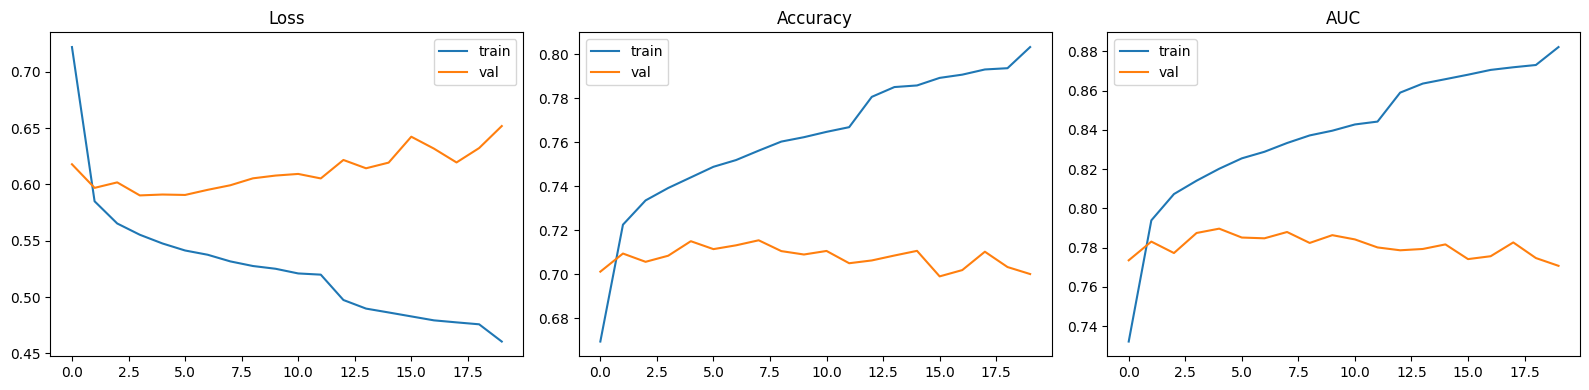

In [189]:
fig,axes=plt.subplots(1,3,figsize=(16,4))
axes[0].plot(history.history['loss'],label='train')
axes[0].plot(history.history['val_loss'],label='val')
axes[0].set_title('Loss'); 
axes[0].legend()
axes[1].plot(history.history['accuracy'],label='train')
axes[1].plot(history.history['val_accuracy'],label='val')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[2].plot(history.history['auc'],label='train')
axes[2].plot(history.history['val_auc'],label='val')
axes[2].set_title('AUC')
axes[2].legend()
plt.tight_layout()  
plt.show()

In [190]:
val_proba=model.predict(X_val,verbose=0).flatten()
test_proba=model.predict(X_test,verbose=0).flatten()
prec,rec,thresholds=precision_recall_curve(y_val,val_proba)
f1_scores=2*prec*rec/(prec+rec+1e-10)
best_idx=np.argmax(f1_scores)
best_thresh=thresholds[best_idx]
best_idx,best_thresh

(14606, 0.2847191)

In [191]:
y_pred=(test_proba>best_thresh).astype(int)
print(classification_report(y_test,y_pred,target_names=['DOWN','UP']))

              precision    recall  f1-score   support

        DOWN       0.78      0.52      0.62     21213
          UP       0.64      0.85      0.73     21689

    accuracy                           0.69     42902
   macro avg       0.71      0.69      0.68     42902
weighted avg       0.71      0.69      0.68     42902



In [192]:
accuracy_score(y_test,y_pred)

0.687100834459932

In [193]:
confidence_bins=[(0.0,0.1),(0.1,0.2),(0.2,0.3),(0.3,0.4),(0.4,0.45),(0.45,0.5),(0.5,0.55),(0.55,0.6),(0.6,0.7),(0.7,0.8),(0.8,0.9),(0.9,1.0)]
print('Accuracy by Confidence Level:')
for low,high in confidence_bins:
    mask=(test_proba>=low)&(test_proba<high)  
    if mask.sum()>0: 
        conf_accuracy=accuracy_score(y_test[mask.flatten()],y_pred[mask.flatten()])
        print(f'{low:.2f}-{high:.2f}: {conf_accuracy:.4f} ({mask.sum()} predictions)')

Accuracy by Confidence Level:
0.00-0.10: 0.8856 (3462 predictions)
0.10-0.20: 0.7775 (6437 predictions)
0.20-0.30: 0.6291 (5018 predictions)
0.30-0.40: 0.4133 (4324 predictions)
0.40-0.45: 0.4915 (1996 predictions)
0.45-0.50: 0.5494 (2073 predictions)
0.50-0.55: 0.5671 (2049 predictions)
0.55-0.60: 0.6124 (2105 predictions)
0.60-0.70: 0.6612 (4049 predictions)
0.70-0.80: 0.7259 (4188 predictions)
0.80-0.90: 0.8205 (4779 predictions)
0.90-1.00: 0.9306 (2422 predictions)


In [194]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[10974 10239]
 [ 3185 18504]]


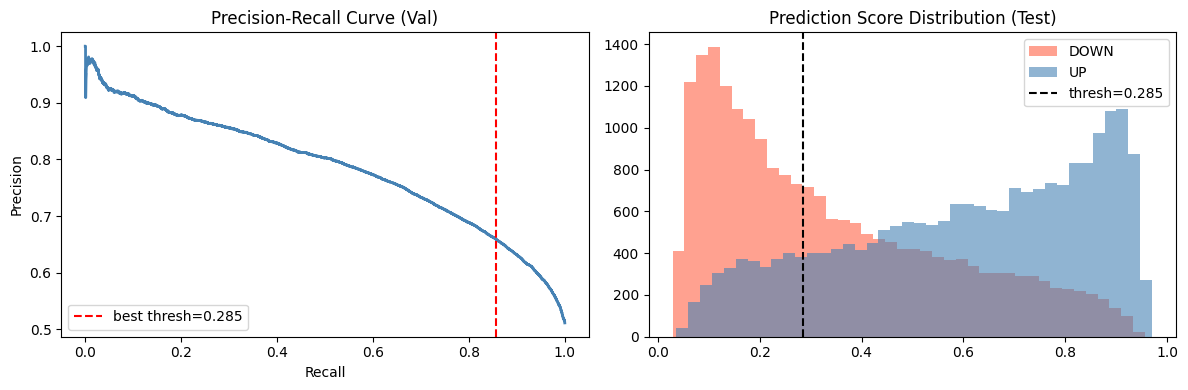

In [195]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(rec,prec,color='steelblue',linewidth=2)
axes[0].axvline(rec[best_idx],color='red',linestyle='--',label=f'best thresh={best_thresh:.3f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve (Val)')
axes[0].legend()
axes[1].hist(test_proba[y_test==0],bins=40,alpha=0.6,label='DOWN',color='tomato')
axes[1].hist(test_proba[y_test==1],bins=40,alpha=0.6,label='UP',color='steelblue')
axes[1].axvline(best_thresh,color='black',linestyle='--',label=f'thresh={best_thresh:.3f}')
axes[1].set_title('Prediction Score Distribution (Test)')
axes[1].legend()
plt.tight_layout()
plt.show()

In [53]:
model.save('models/rnn_btc_overlap.keras')
with open('scalers/scaler.pkl','wb') as f:
    pickle.dump(scaler,f)

In [7]:
data=pd.read_csv('BTC_22-26_5min.csv')
# data['upper_wick']=np.where(data['color']==1,data['high']-data['close'],data['high']-data['open'])
# data['lower_wick']=np.where(data['color']==1,data['open']-data['low'],data['close']-data['low'])
# data['body_to_range']=data['body']/(data['high']-data['low']+1e-10)
# data['upper_wick_ratio']=data['upper_wick']/(data['high']-data['low']+1e-10)
# data['lower_wick_ratio']=data['lower_wick']/(data['high']-data['low']+1e-10)
data['price_change']=data['close'].pct_change(5)
data['price_change_2']=data['close'].pct_change(10)
data['price_change_3']=data['close'].pct_change(15)
data['price_change_4']=data['close'].pct_change(20)
data['price_change_5']=data['close'].pct_change(25)
data['price_change_6']=data['close'].pct_change(30)
# data['sma_5']=data['close'].rolling(25).mean()
# data['close_to_sma10']=(data['close']-data['sma_10'])/data['sma_10']
# data['volatility']=data['close'].rolling(30).std()
data['volume']=pd.to_numeric(data['volume'])
data['taker_volume']=pd.to_numeric(data['taker_volume'])
data['no_of_trades']=pd.to_numeric(data['no_of_trades'])
data['taker_buy_ratio']=data['taker_volume']/(data['volume']+1e-10)
data['avg_trade_size']=data['volume']/(data['no_of_trades']+1e-10)
data['datetime']=pd.to_datetime(data['datetime'])
data.set_index('datetime',inplace=True)
data['realised_vol']=data['close'].pct_change().rolling(12).std()
FORWARD_BARS=24
UP_THRESH=0.000001
DN_THRESH=-0.000001
future_return=(data['close'].shift(-FORWARD_BARS)-data['close'])/data['close']  
data['label']=np.where(future_return>UP_THRESH,1,np.where(future_return<DN_THRESH,0,np.nan))  
data['date']=data.index.date
df=data.between_time('00:00','23:55')
all_dates=sorted(df['date'].unique())
split_idx=int(len(all_dates)*0.7)
val_idx=int(len(all_dates)*0.85)
train_dates=all_dates[:split_idx]
val_dates=all_dates[split_idx:val_idx]
test_dates=all_dates[val_idx:]
train_data=df[df['date'].isin(train_dates)].copy()
val_data=df[df['date'].isin(val_dates)].copy()
test_data=df[df['date'].isin(test_dates)].copy()
ROLL=240
vol_mean=df['volume'].rolling(ROLL,min_periods=1).mean()
vol_std=df['volume'].rolling(ROLL,min_periods=1).std().replace(0,1e-10)
df['vol_z']=(df['volume']-vol_mean)/vol_std
train_data['vol_z']=df.loc[train_data.index,'vol_z']
val_data['vol_z']=df.loc[val_data.index,'vol_z']
test_data['vol_z']=df.loc[test_data.index,'vol_z']
feature_cols=['price_change','price_change_2','price_change_3','price_change_4','price_change_5','price_change_6','avg_trade_size','taker_buy_ratio','vol_z','realised_vol']
scaler=RobustScaler()
train_data[feature_cols]=scaler.fit_transform(train_data[feature_cols])
val_data[feature_cols]=scaler.transform(val_data[feature_cols])
test_data[feature_cols]=scaler.transform(test_data[feature_cols])
SEQ_LEN=72
def build_sequences(df,seq_len=SEQ_LEN):
    X,y=[],[]
    for date,group in df.groupby('date'):
        group=group.dropna(subset=feature_cols+['label'])
        group=group.reset_index(drop=True)
        if len(group)<seq_len+1:
            continue
        for i in range(seq_len,len(group)):
            label=group.iloc[i]['label']
            if np.isnan(label):
                continue
            seq=group.iloc[i-seq_len:i][feature_cols].values
            if np.isnan(seq).any():
                continue 
            X.append(seq)
            y.append(int(label))
    return np.array(X,dtype=np.float32),np.array(y,dtype=np.float32)
X_train,y_train=build_sequences(train_data)
X_val,y_val=build_sequences(val_data)
X_test,y_test=build_sequences(test_data)
cw_arr=compute_class_weight('balanced',classes=np.array([0,1]),y=y_train)
class_weights={0:cw_arr[0],1:cw_arr[1]}
n_features=len(feature_cols)
model=Sequential([
    Input(shape=(SEQ_LEN,n_features)),
    Bidirectional(LSTM(64,return_sequences=True,kernel_regularizer=l2(1e-3),recurrent_regularizer=l2(1e-3))),
    LayerNormalization(),
    Dropout(0.4),
    Bidirectional(LSTM(32,return_sequences=False,kernel_regularizer=l2(1e-3))),
    LayerNormalization(),
    Dropout(0.4),
    Dense(32,activation='relu'),
    BatchNormalization(),
    # Dropout(0.3),
    Dense(1,activation='sigmoid')
])
model.compile(loss='binary_crossentropy',optimizer=Adam(learning_rate=1e-3),metrics=['accuracy',AUC(name='auc')])
callbacks=[
    EarlyStopping(monitor='val_auc',patience=15,restore_best_weights=True,mode='max',verbose=1),
    ReduceLROnPlateau(monitor='val_auc',factor=0.5,patience=7,min_lr=1e-7,mode='max',verbose=1),
]
history=model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=100,batch_size=32,class_weight=class_weights,callbacks=callbacks,verbose=1)

Epoch 1/100
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 341s 45ms/step - accuracy: 0.7007 - auc: 0.7731 - loss: 0.6514 - val_accuracy: 0.7073 - val_auc: 0.8090 - val_loss: 0.6130 - learning_rate: 0.0010
Epoch 2/100
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 318s 43ms/step - accuracy: 0.7553 - auc: 0.8335 - loss: 0.5393 - val_accuracy: 0.7467 - val_auc: 0.8308 - val_loss: 0.5632 - learning_rate: 0.0010
Epoch 3/100
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 297s 40ms/step - accuracy: 0.7666 - auc: 0.8466 - loss: 0.5173 - val_accuracy: 0.7539 - val_auc: 0.8341 - val_loss: 0.5395 - learning_rate: 0.0010
Epoch 4/100
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 304s 41ms/step - accuracy: 0.7721 - auc: 0.8527 - loss: 0.5062 - val_accuracy: 0.7528 - val_auc: 0.8366 - val_loss: 0.5303 - learning_rate: 0.0010
Epoch 5/100
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 304s 41ms/step - accuracy: 0.7746 - auc: 0.8566 - loss: 0.4990 - val_accuracy: 0.7531 - val_auc: 0.8329 - val_loss: 0.5375 - learning_rate: 0.0010
Epoch 6/100
7430/7430 ━━━━━━━━━━━━━━━━━━━━ 304s 41

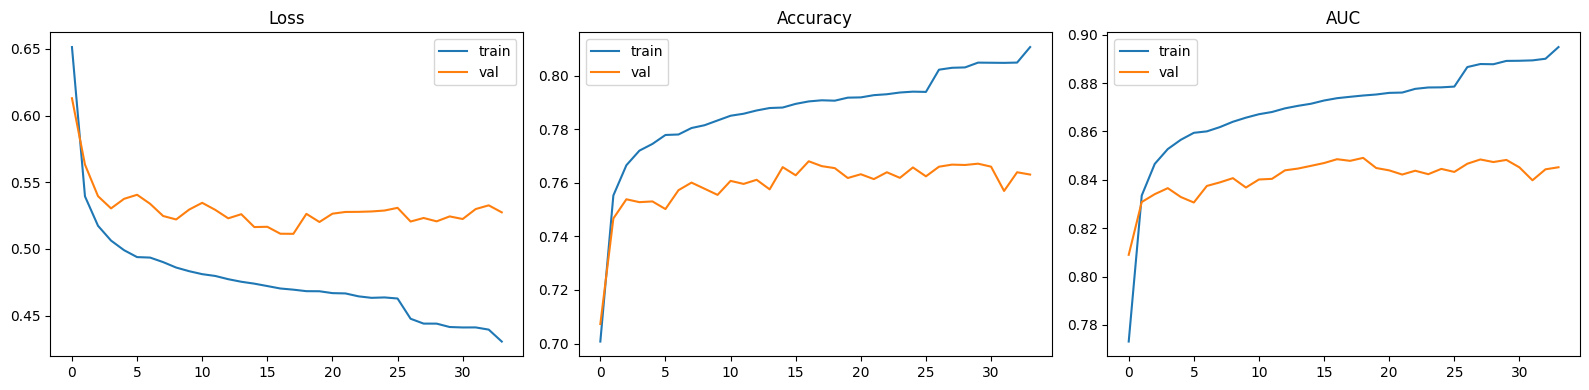

In [8]:
fig,axes=plt.subplots(1,3,figsize=(16,4))
axes[0].plot(history.history['loss'],label='train')
axes[0].plot(history.history['val_loss'],label='val')
axes[0].set_title('Loss'); 
axes[0].legend()
axes[1].plot(history.history['accuracy'],label='train')
axes[1].plot(history.history['val_accuracy'],label='val')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[2].plot(history.history['auc'],label='train')
axes[2].plot(history.history['val_auc'],label='val')
axes[2].set_title('AUC')
axes[2].legend()
plt.tight_layout()  
plt.show()

In [9]:
val_proba=model.predict(X_val,verbose=0).flatten()
test_proba=model.predict(X_test,verbose=0).flatten()
prec,rec,thresholds=precision_recall_curve(y_val,val_proba)
f1_scores=2*prec*rec/(prec+rec+1e-10)
best_idx=np.argmax(f1_scores)
best_thresh=thresholds[best_idx]
y_pred=(test_proba>best_thresh).astype(int)
print(classification_report(y_test,y_pred,target_names=['DOWN','UP']))
print(accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

        DOWN       0.81      0.67      0.73     25286
          UP       0.72      0.85      0.78     25808

    accuracy                           0.76     51094
   macro avg       0.77      0.76      0.76     51094
weighted avg       0.77      0.76      0.76     51094

0.7601871061181352


In [10]:
confidence_bins=[(0.0,0.1),(0.1,0.2),(0.2,0.3),(0.3,0.4),(0.4,0.45),(0.45,0.5),(0.5,0.55),(0.55,0.6),(0.6,0.7),(0.7,0.8),(0.8,0.9),(0.9,1.0)]
print('Accuracy by Confidence Level:')
for low,high in confidence_bins:
    mask=(test_proba>=low)&(test_proba<high)  
    if mask.sum()>0: 
        conf_accuracy=accuracy_score(y_test[mask.flatten()],y_pred[mask.flatten()])
        print(f'{low:.2f}-{high:.2f}: {conf_accuracy:.4f} ({mask.sum()} predictions)')

Accuracy by Confidence Level:
0.00-0.10: 0.9351 (7637 predictions)
0.10-0.20: 0.8427 (3987 predictions)
0.20-0.30: 0.7568 (3581 predictions)
0.30-0.40: 0.6937 (3252 predictions)
0.40-0.45: 0.6388 (1531 predictions)
0.45-0.50: 0.4965 (1716 predictions)
0.50-0.55: 0.4650 (1658 predictions)
0.55-0.60: 0.4913 (1722 predictions)
0.60-0.70: 0.5624 (3798 predictions)
0.70-0.80: 0.6384 (4491 predictions)
0.80-0.90: 0.7639 (6103 predictions)
0.90-1.00: 0.8833 (11618 predictions)


In [11]:
data=pd.read_csv('BTC_22-26_5min.csv')
# data['upper_wick']=np.where(data['color']==1,data['high']-data['close'],data['high']-data['open'])
# data['lower_wick']=np.where(data['color']==1,data['open']-data['low'],data['close']-data['low'])
# data['body_to_range']=data['body']/(data['high']-data['low']+1e-10)
# data['upper_wick_ratio']=data['upper_wick']/(data['high']-data['low']+1e-10)
# data['lower_wick_ratio']=data['lower_wick']/(data['high']-data['low']+1e-10)
data['price_change']=data['close'].pct_change(5)
data['price_change_2']=data['close'].pct_change(10)
data['price_change_3']=data['close'].pct_change(15)
data['price_change_4']=data['close'].pct_change(20)
data['price_change_5']=data['close'].pct_change(25)
data['price_change_6']=data['close'].pct_change(30)
# data['sma_5']=data['close'].rolling(25).mean()
# data['close_to_sma10']=(data['close']-data['sma_10'])/data['sma_10']
# data['volatility']=data['close'].rolling(30).std()
data['volume']=pd.to_numeric(data['volume'])
data['taker_volume']=pd.to_numeric(data['taker_volume'])
data['no_of_trades']=pd.to_numeric(data['no_of_trades'])
data['taker_buy_ratio']=data['taker_volume']/(data['volume']+1e-10)
data['avg_trade_size']=data['volume']/(data['no_of_trades']+1e-10)
data['datetime']=pd.to_datetime(data['datetime'])
data.set_index('datetime',inplace=True)
data['realised_vol']=data['close'].pct_change().rolling(12).std()
FORWARD_BARS=24
UP_THRESH=0.0000001
DN_THRESH=-0.0000001
future_return=(data['close'].shift(-FORWARD_BARS)-data['close'])/data['close']  
data['label']=np.where(future_return>UP_THRESH,1,np.where(future_return<DN_THRESH,0,np.nan))  
data['date']=data.index.date
df=data.between_time('00:00','23:55')
all_dates=sorted(df['date'].unique())
split_idx=int(len(all_dates)*0.7)
val_idx=int(len(all_dates)*0.85)
train_dates=all_dates[:split_idx]
val_dates=all_dates[split_idx:val_idx]
test_dates=all_dates[val_idx:]
train_data=df[df['date'].isin(train_dates)].copy()
val_data=df[df['date'].isin(val_dates)].copy()
test_data=df[df['date'].isin(test_dates)].copy()
ROLL=240
vol_mean=df['volume'].rolling(ROLL,min_periods=1).mean()
vol_std=df['volume'].rolling(ROLL,min_periods=1).std().replace(0,1e-10)
df['vol_z']=(df['volume']-vol_mean)/vol_std
train_data['vol_z']=df.loc[train_data.index,'vol_z']
val_data['vol_z']=df.loc[val_data.index,'vol_z']
test_data['vol_z']=df.loc[test_data.index,'vol_z']
feature_cols=['price_change','price_change_2','price_change_3','price_change_4','price_change_5','price_change_6','avg_trade_size','taker_buy_ratio','vol_z','realised_vol']
scaler=RobustScaler()
train_data[feature_cols]=scaler.fit_transform(train_data[feature_cols])
val_data[feature_cols]=scaler.transform(val_data[feature_cols])
test_data[feature_cols]=scaler.transform(test_data[feature_cols])
SEQ_LEN=72
def build_sequences(df,seq_len=SEQ_LEN):
    X,y=[],[]
    for date,group in df.groupby('date'):
        group=group.dropna(subset=feature_cols+['label'])
        group=group.reset_index(drop=True)
        if len(group)<seq_len+1:
            continue
        for i in range(seq_len,len(group)):
            label=group.iloc[i]['label']
            if np.isnan(label):
                continue
            seq=group.iloc[i-seq_len:i][feature_cols].values
            if np.isnan(seq).any():
                continue 
            X.append(seq)
            y.append(int(label))
    return np.array(X,dtype=np.float32),np.array(y,dtype=np.float32)
X_train,y_train=build_sequences(train_data)
X_val,y_val=build_sequences(val_data)
X_test,y_test=build_sequences(test_data)
cw_arr=compute_class_weight('balanced',classes=np.array([0,1]),y=y_train)
class_weights={0:cw_arr[0],1:cw_arr[1]}
n_features=len(feature_cols)
model=Sequential([
    Input(shape=(SEQ_LEN,n_features)),
    Bidirectional(LSTM(64,return_sequences=True,kernel_regularizer=l2(1e-3),recurrent_regularizer=l2(1e-3))),
    LayerNormalization(),
    Dropout(0.4),
    Bidirectional(LSTM(32,return_sequences=False,kernel_regularizer=l2(1e-3))),
    LayerNormalization(),
    Dropout(0.4),
    Dense(32,activation='relu'),
    BatchNormalization(),
    # Dropout(0.3),
    Dense(1,activation='sigmoid')
])
model.compile(loss='binary_crossentropy',optimizer=Adam(learning_rate=1e-3),metrics=['accuracy',AUC(name='auc')])
callbacks=[
    EarlyStopping(monitor='val_auc',patience=15,restore_best_weights=True,mode='max',verbose=1),
    ReduceLROnPlateau(monitor='val_auc',factor=0.5,patience=7,min_lr=1e-7,mode='max',verbose=1),
]
history=model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=100,batch_size=32,class_weight=class_weights,callbacks=callbacks,verbose=1)

Epoch 1/100
7431/7431 ━━━━━━━━━━━━━━━━━━━━ 384s 51ms/step - accuracy: 0.7039 - auc: 0.7766 - loss: 0.6519 - val_accuracy: 0.7358 - val_auc: 0.8155 - val_loss: 0.5669 - learning_rate: 0.0010
Epoch 2/100
7431/7431 ━━━━━━━━━━━━━━━━━━━━ 319s 43ms/step - accuracy: 0.7581 - auc: 0.8361 - loss: 0.5347 - val_accuracy: 0.7521 - val_auc: 0.8310 - val_loss: 0.5432 - learning_rate: 0.0010
Epoch 3/100
7431/7431 ━━━━━━━━━━━━━━━━━━━━ 330s 44ms/step - accuracy: 0.7683 - auc: 0.8474 - loss: 0.5148 - val_accuracy: 0.7528 - val_auc: 0.8328 - val_loss: 0.5354 - learning_rate: 0.0010
Epoch 4/100
7431/7431 ━━━━━━━━━━━━━━━━━━━━ 336s 45ms/step - accuracy: 0.7710 - auc: 0.8514 - loss: 0.5073 - val_accuracy: 0.7557 - val_auc: 0.8367 - val_loss: 0.5264 - learning_rate: 0.0010
Epoch 5/100
7431/7431 ━━━━━━━━━━━━━━━━━━━━ 358s 48ms/step - accuracy: 0.7745 - auc: 0.8551 - loss: 0.5004 - val_accuracy: 0.7485 - val_auc: 0.8320 - val_loss: 0.5324 - learning_rate: 0.0010
Epoch 6/100
7431/7431 ━━━━━━━━━━━━━━━━━━━━ 353s 48

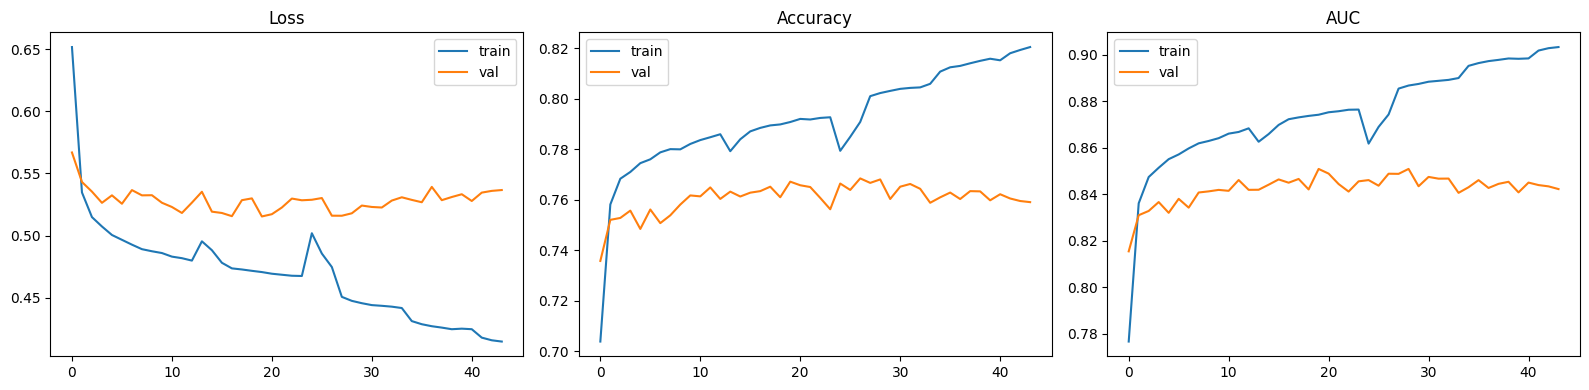

In [15]:
fig,axes=plt.subplots(1,3,figsize=(16,4))
axes[0].plot(history.history['loss'],label='train')
axes[0].plot(history.history['val_loss'],label='val')
axes[0].set_title('Loss'); 
axes[0].legend()
axes[1].plot(history.history['accuracy'],label='train')
axes[1].plot(history.history['val_accuracy'],label='val')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[2].plot(history.history['auc'],label='train')
axes[2].plot(history.history['val_auc'],label='val')
axes[2].set_title('AUC')
axes[2].legend()
plt.tight_layout()  
plt.show()

In [29]:
val_proba=model.predict(X_val,verbose=0).flatten()
test_proba=model.predict(X_test,verbose=0).flatten()
prec,rec,thresholds=precision_recall_curve(y_val,val_proba)
f1_scores=2*prec*rec/(prec+rec+1e-10)
best_idx=np.argmax(f1_scores)
best_thresh=thresholds[best_idx]
y_pred=(test_proba>best_thresh).astype(int)
print(classification_report(y_test,y_pred,target_names=['DOWN','UP']))
print(accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

        DOWN       0.81      0.68      0.74     25291
          UP       0.73      0.84      0.78     25824

    accuracy                           0.76     51115
   macro avg       0.77      0.76      0.76     51115
weighted avg       0.77      0.76      0.76     51115

0.7631810623104763


In [30]:
confidence_bins=[(0.0,0.1),(0.1,0.2),(0.2,0.3),(0.3,0.4),(0.4,0.45),(0.45,0.5),(0.5,0.55),(0.55,0.6),(0.6,0.7),(0.7,0.8),(0.8,0.9),(0.9,1.0)]
print('Accuracy by Confidence Level:')
for low,high in confidence_bins:
    mask=(test_proba>=low)&(test_proba<high)  
    if mask.sum()>0: 
        conf_accuracy=accuracy_score(y_test[mask.flatten()],y_pred[mask.flatten()])
        print(f'{low:.2f}-{high:.2f}: {conf_accuracy:.4f} ({mask.sum()} predictions)')

Accuracy by Confidence Level:
0.00-0.10: 0.9328 (7518 predictions)
0.10-0.20: 0.8475 (4065 predictions)
0.20-0.30: 0.7811 (3495 predictions)
0.30-0.40: 0.6861 (3437 predictions)
0.40-0.45: 0.6177 (1724 predictions)
0.45-0.50: 0.5170 (1710 predictions)
0.50-0.55: 0.4625 (1922 predictions)
0.55-0.60: 0.5136 (1951 predictions)
0.60-0.70: 0.5940 (4165 predictions)
0.70-0.80: 0.6752 (4366 predictions)
0.80-0.90: 0.7597 (5394 predictions)
0.90-1.00: 0.8888 (11368 predictions)


In [ ]:
model.save('models/rnn_btc_overlap.keras')
with open('scalers/scaler.pkl','wb') as f:
    pickle.dump(scaler,f)